In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split


In [102]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [103]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [104]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [105]:
features = ["pclass", "sex", "fare", "embarked","age"]
target = ["survived"]

In [106]:
# fill the missing data

from sklearn.impute import SimpleImputer

impute_median = SimpleImputer(strategy="median")
titanic[["age"]] = impute_median.fit_transform(titanic[["age"]])

impute_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = impute_freq.fit_transform(titanic[["embarked"]])

titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [107]:
# encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

titanic.head()



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [108]:
X = titanic[features]
y= titanic[target]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)




In [109]:
from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Precision : ", precision_score(y_test , y_pred))
print("Recall : ", recall_score(y_test , y_pred))
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1 Score : ", f1_score(y_test , y_pred))


Precision :  0.7037037037037037
Recall :  0.7702702702702703
Accuracy :  0.770949720670391
f1 Score :  0.7354838709677419


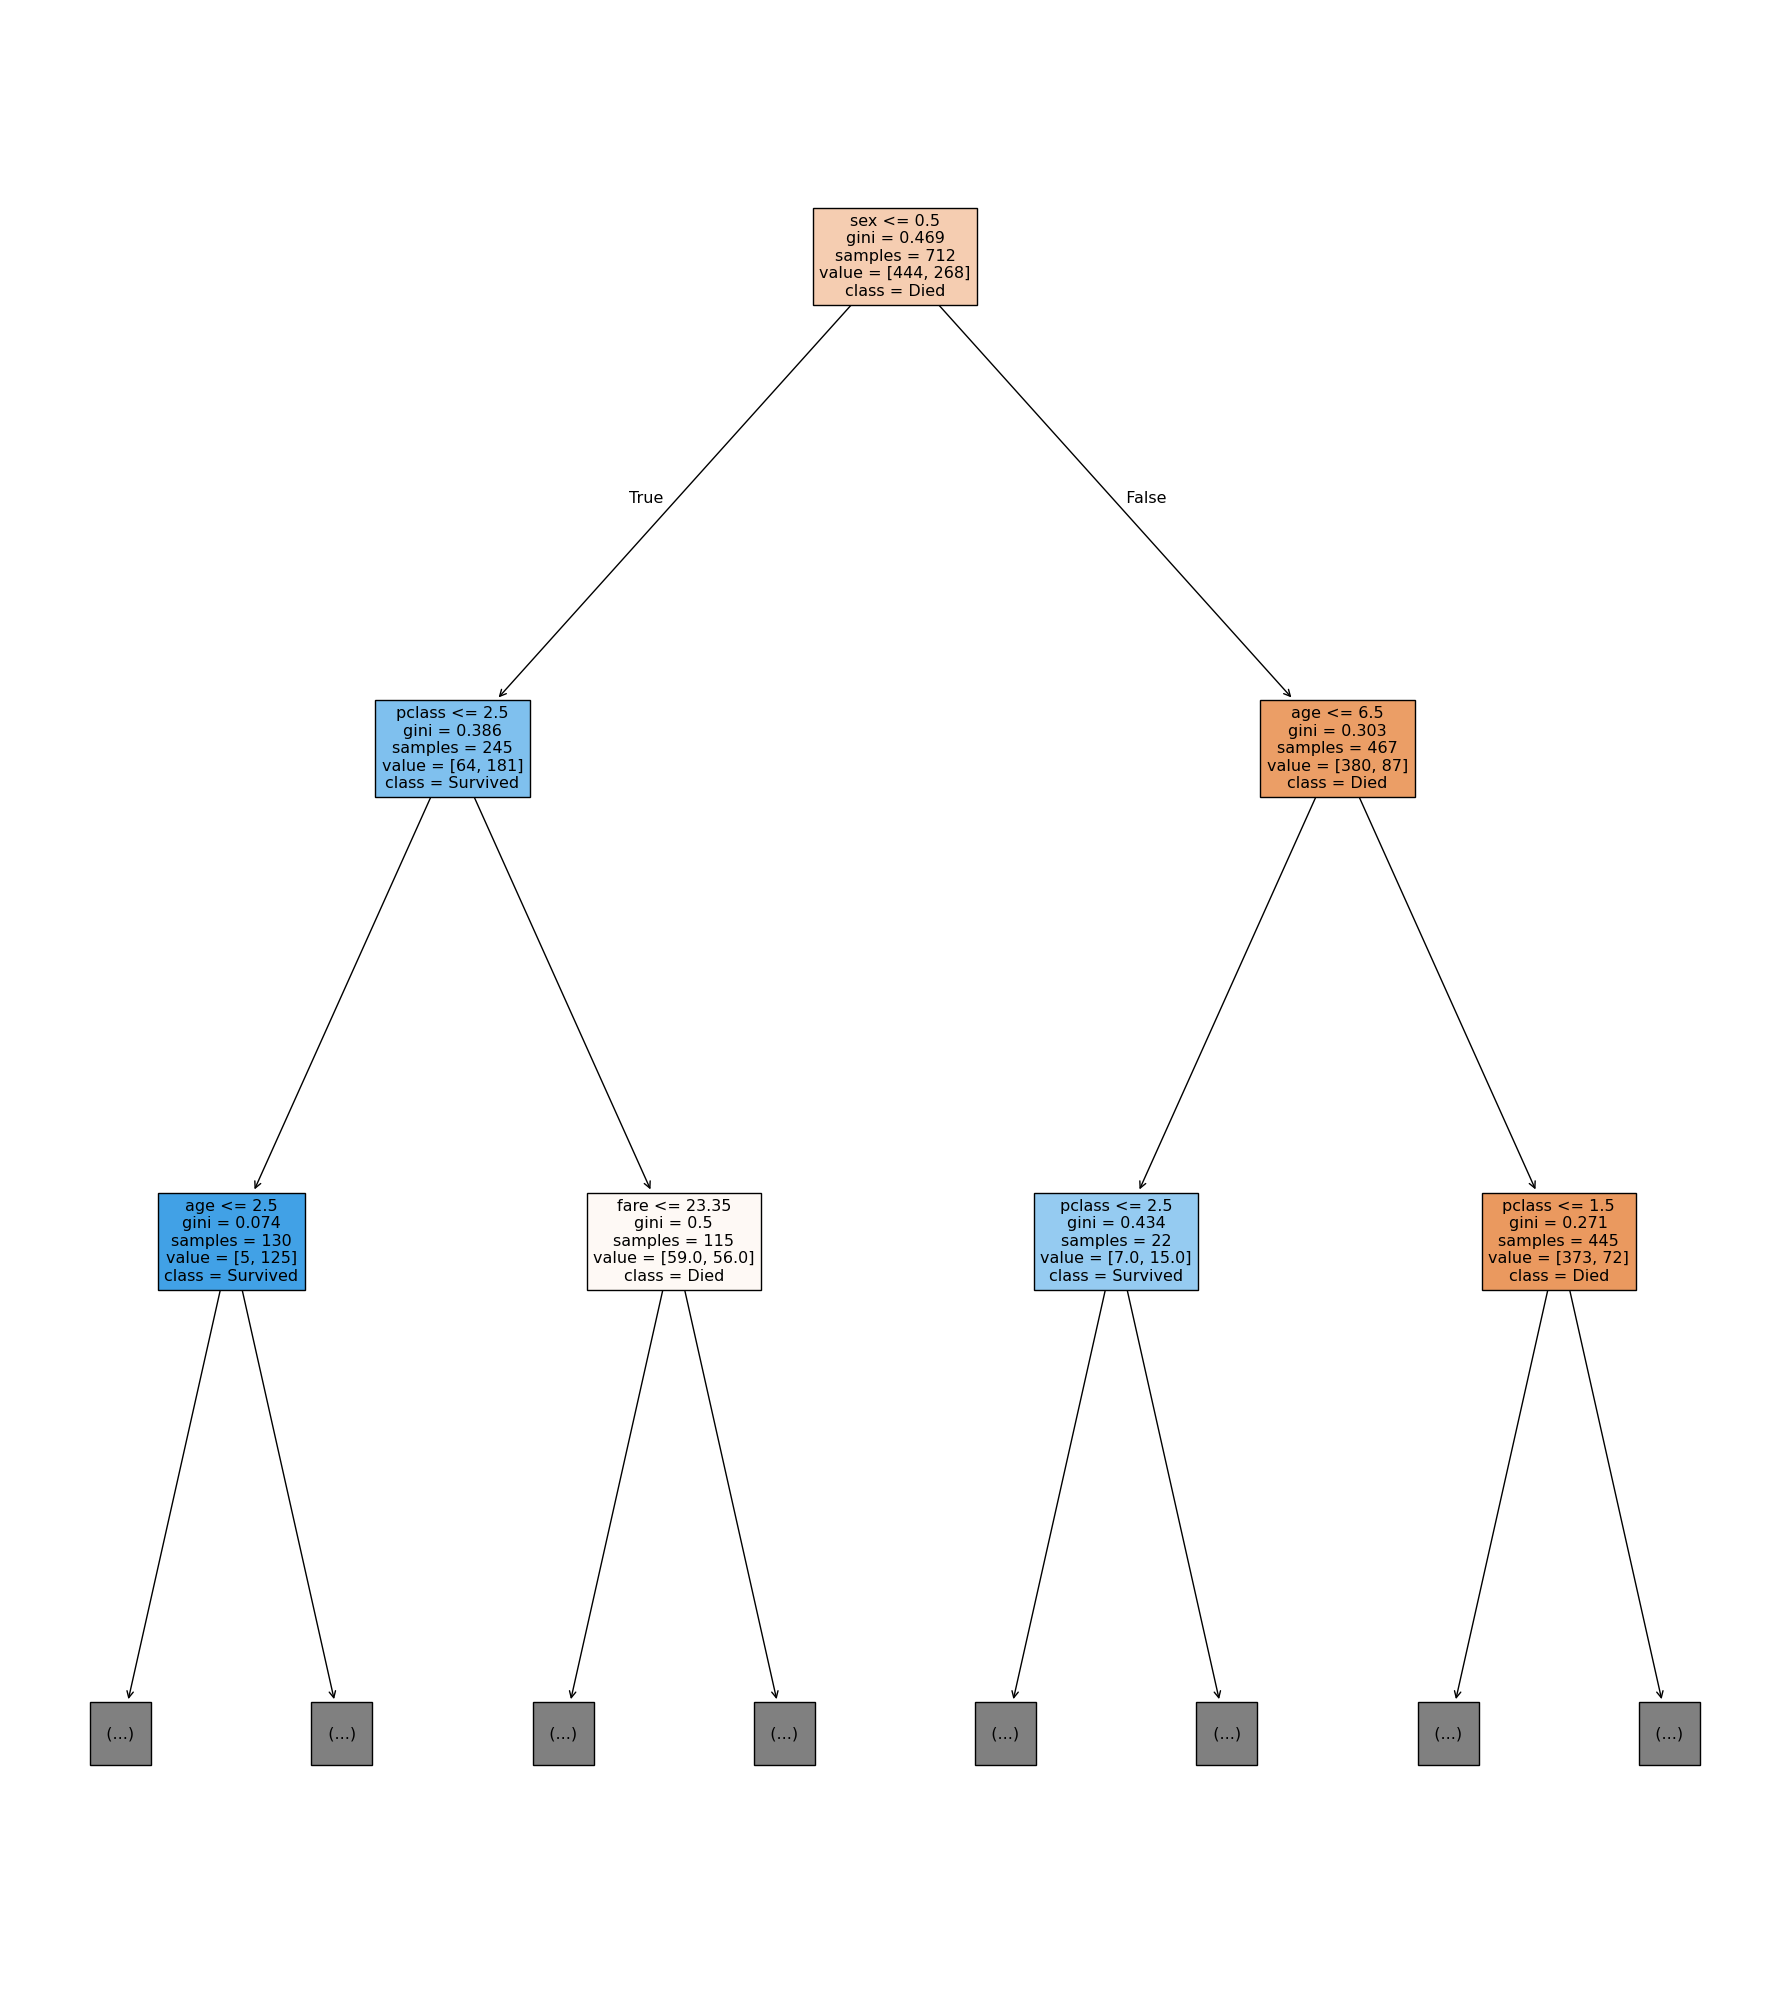

In [110]:
# plot the tree


from sklearn.tree import plot_tree

plt.figure(figsize=(18,20))
plot_tree(
    dt_model , 
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()


## Decision tree with Pre-pruning

Accuracy for depth2 , accuracy = 0.7653631284916201
Accuracy for depth3 , accuracy = 0.7988826815642458
Accuracy for depth4 , accuracy = 0.7988826815642458
Accuracy for depth5 , accuracy = 0.7988826815642458
Accuracy for depth6 , accuracy = 0.7988826815642458
Accuracy for depth7 , accuracy = 0.7932960893854749
Accuracy for depth8 , accuracy = 0.7932960893854749
Accuracy for depth9 , accuracy = 0.7821229050279329
Accuracy for depth10 , accuracy = 0.7932960893854749


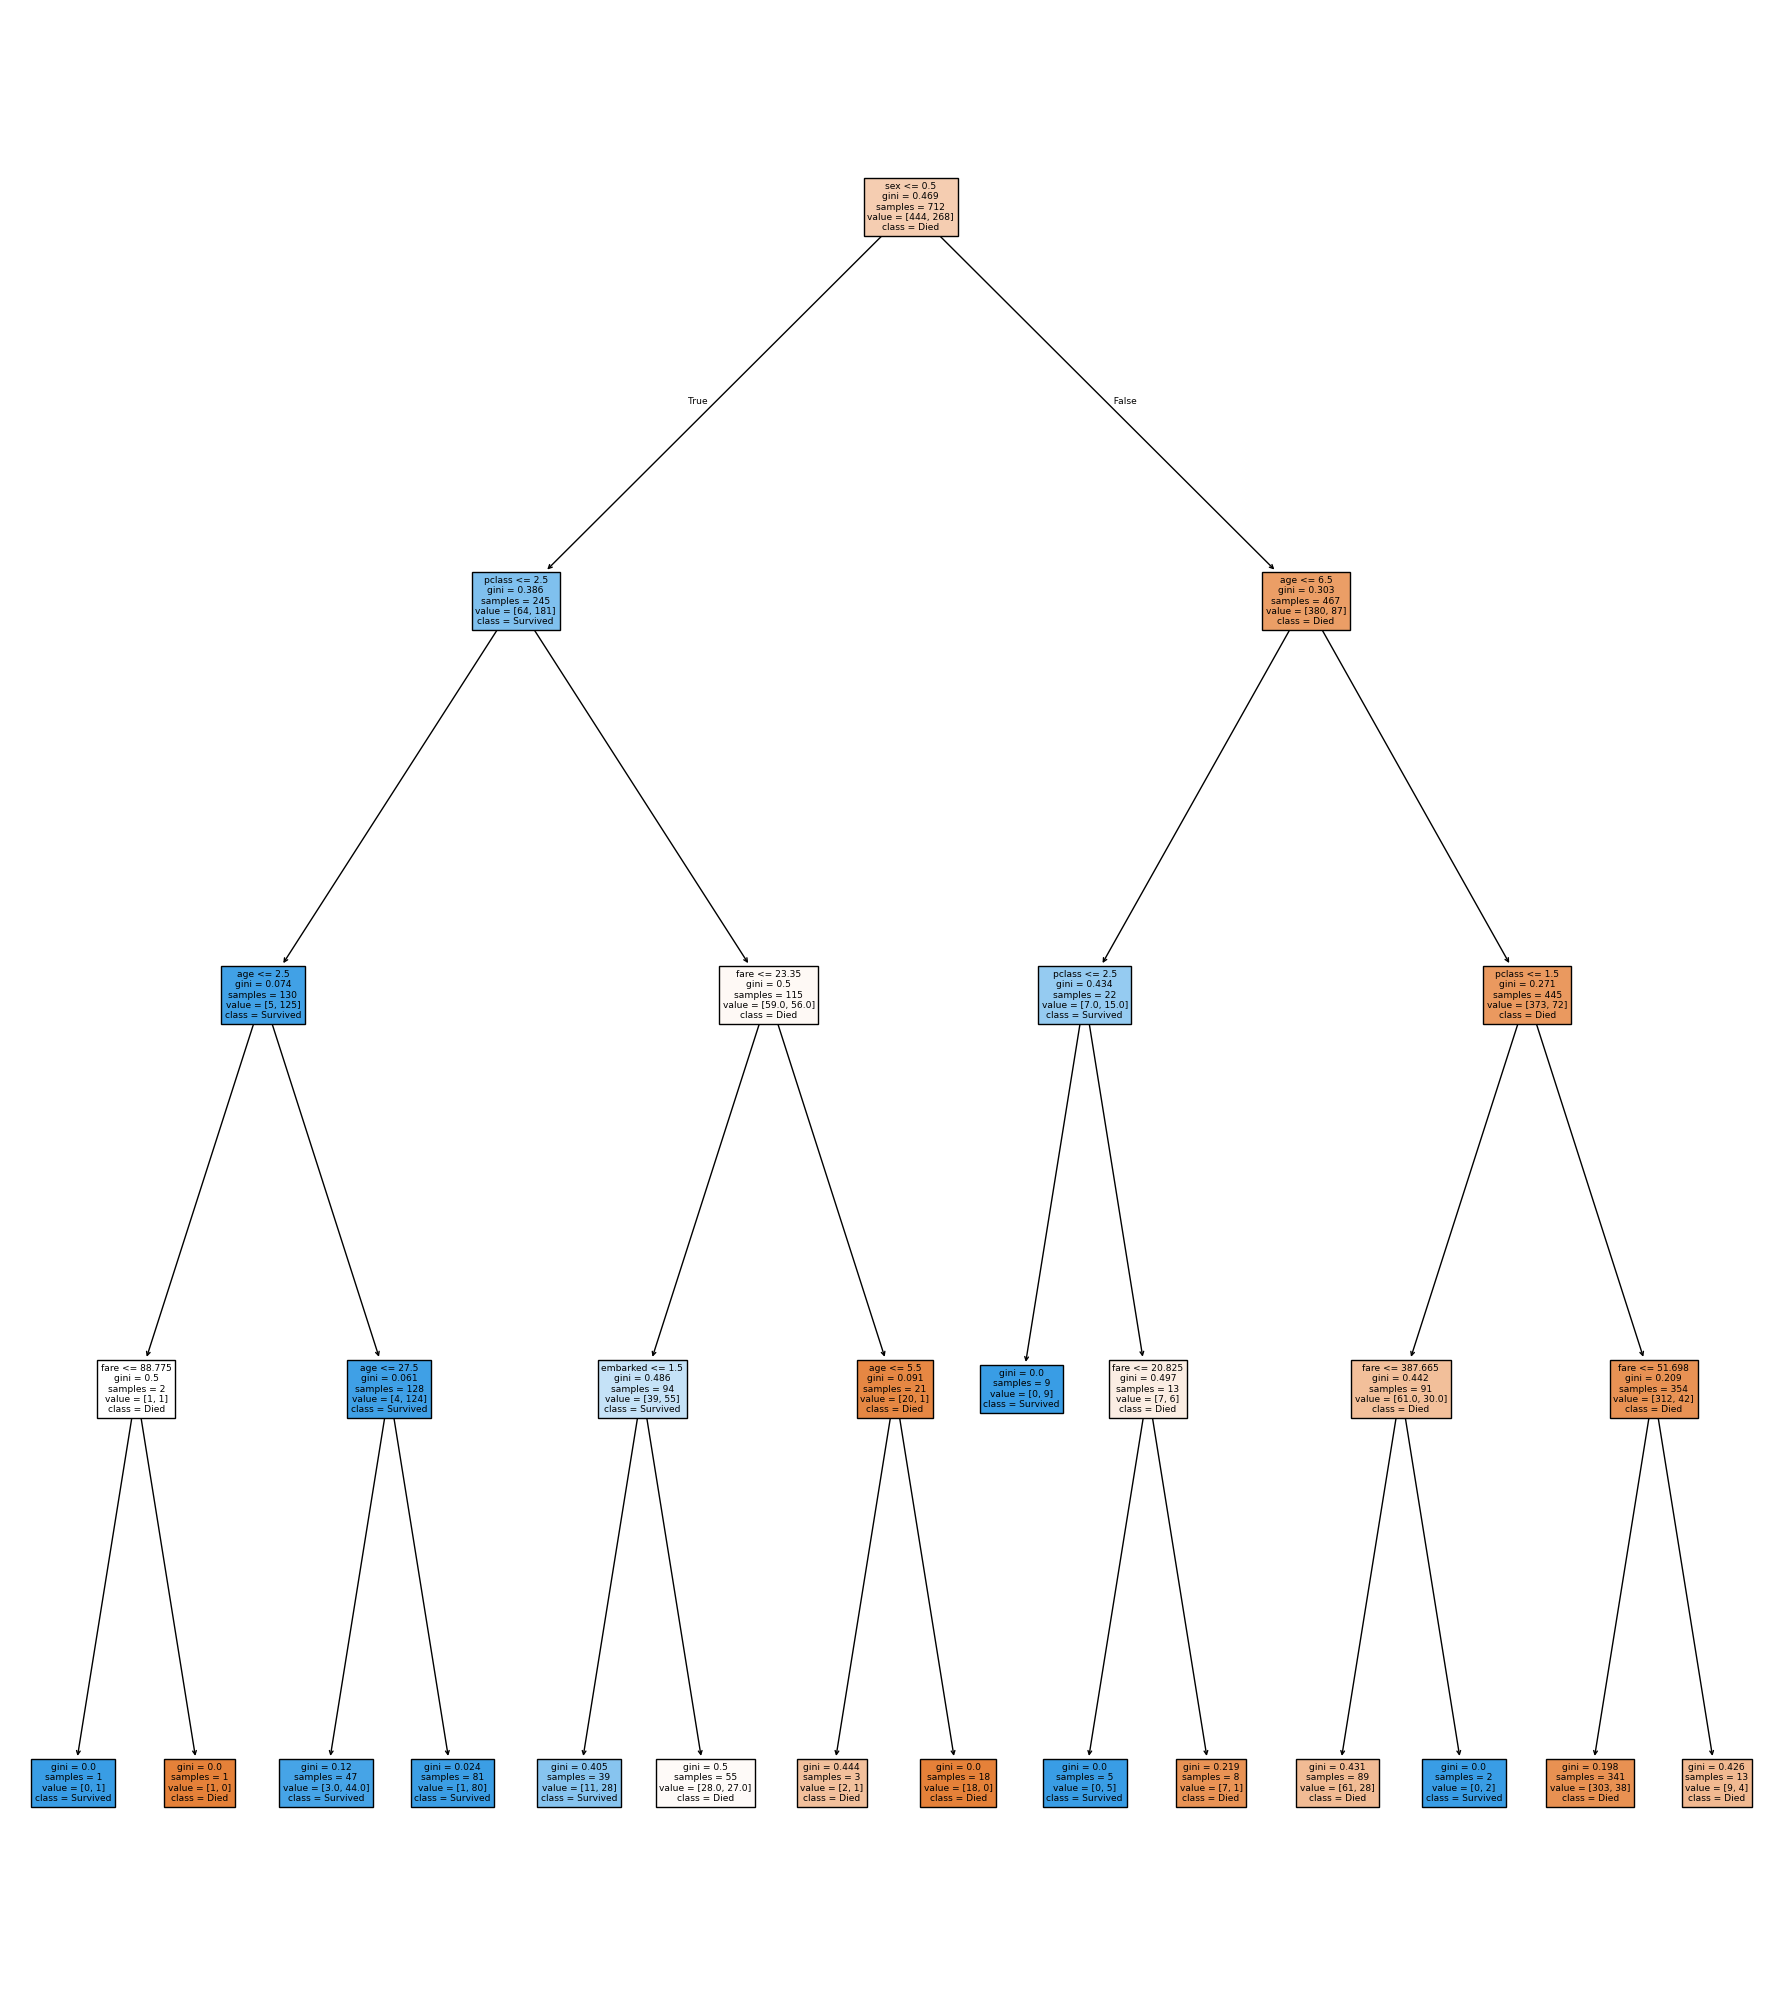

In [114]:
max_depths = [2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"Accuracy for depth{depth} , accuracy = {acc}")

    if depth==4:
        plt.figure(figsize=(18,20))
        plot_tree(
            model , 
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
         
        )

        plt.tight_layout()

Accuracy for split= 5 , accuracy = 0.7988826815642458
Accuracy for split= 10 , accuracy = 0.7988826815642458
Accuracy for split= 15 , accuracy = 0.7988826815642458
Accuracy for split= 20 , accuracy = 0.7988826815642458
Accuracy for split= 25 , accuracy = 0.7932960893854749
Accuracy for split= 30 , accuracy = 0.7932960893854749


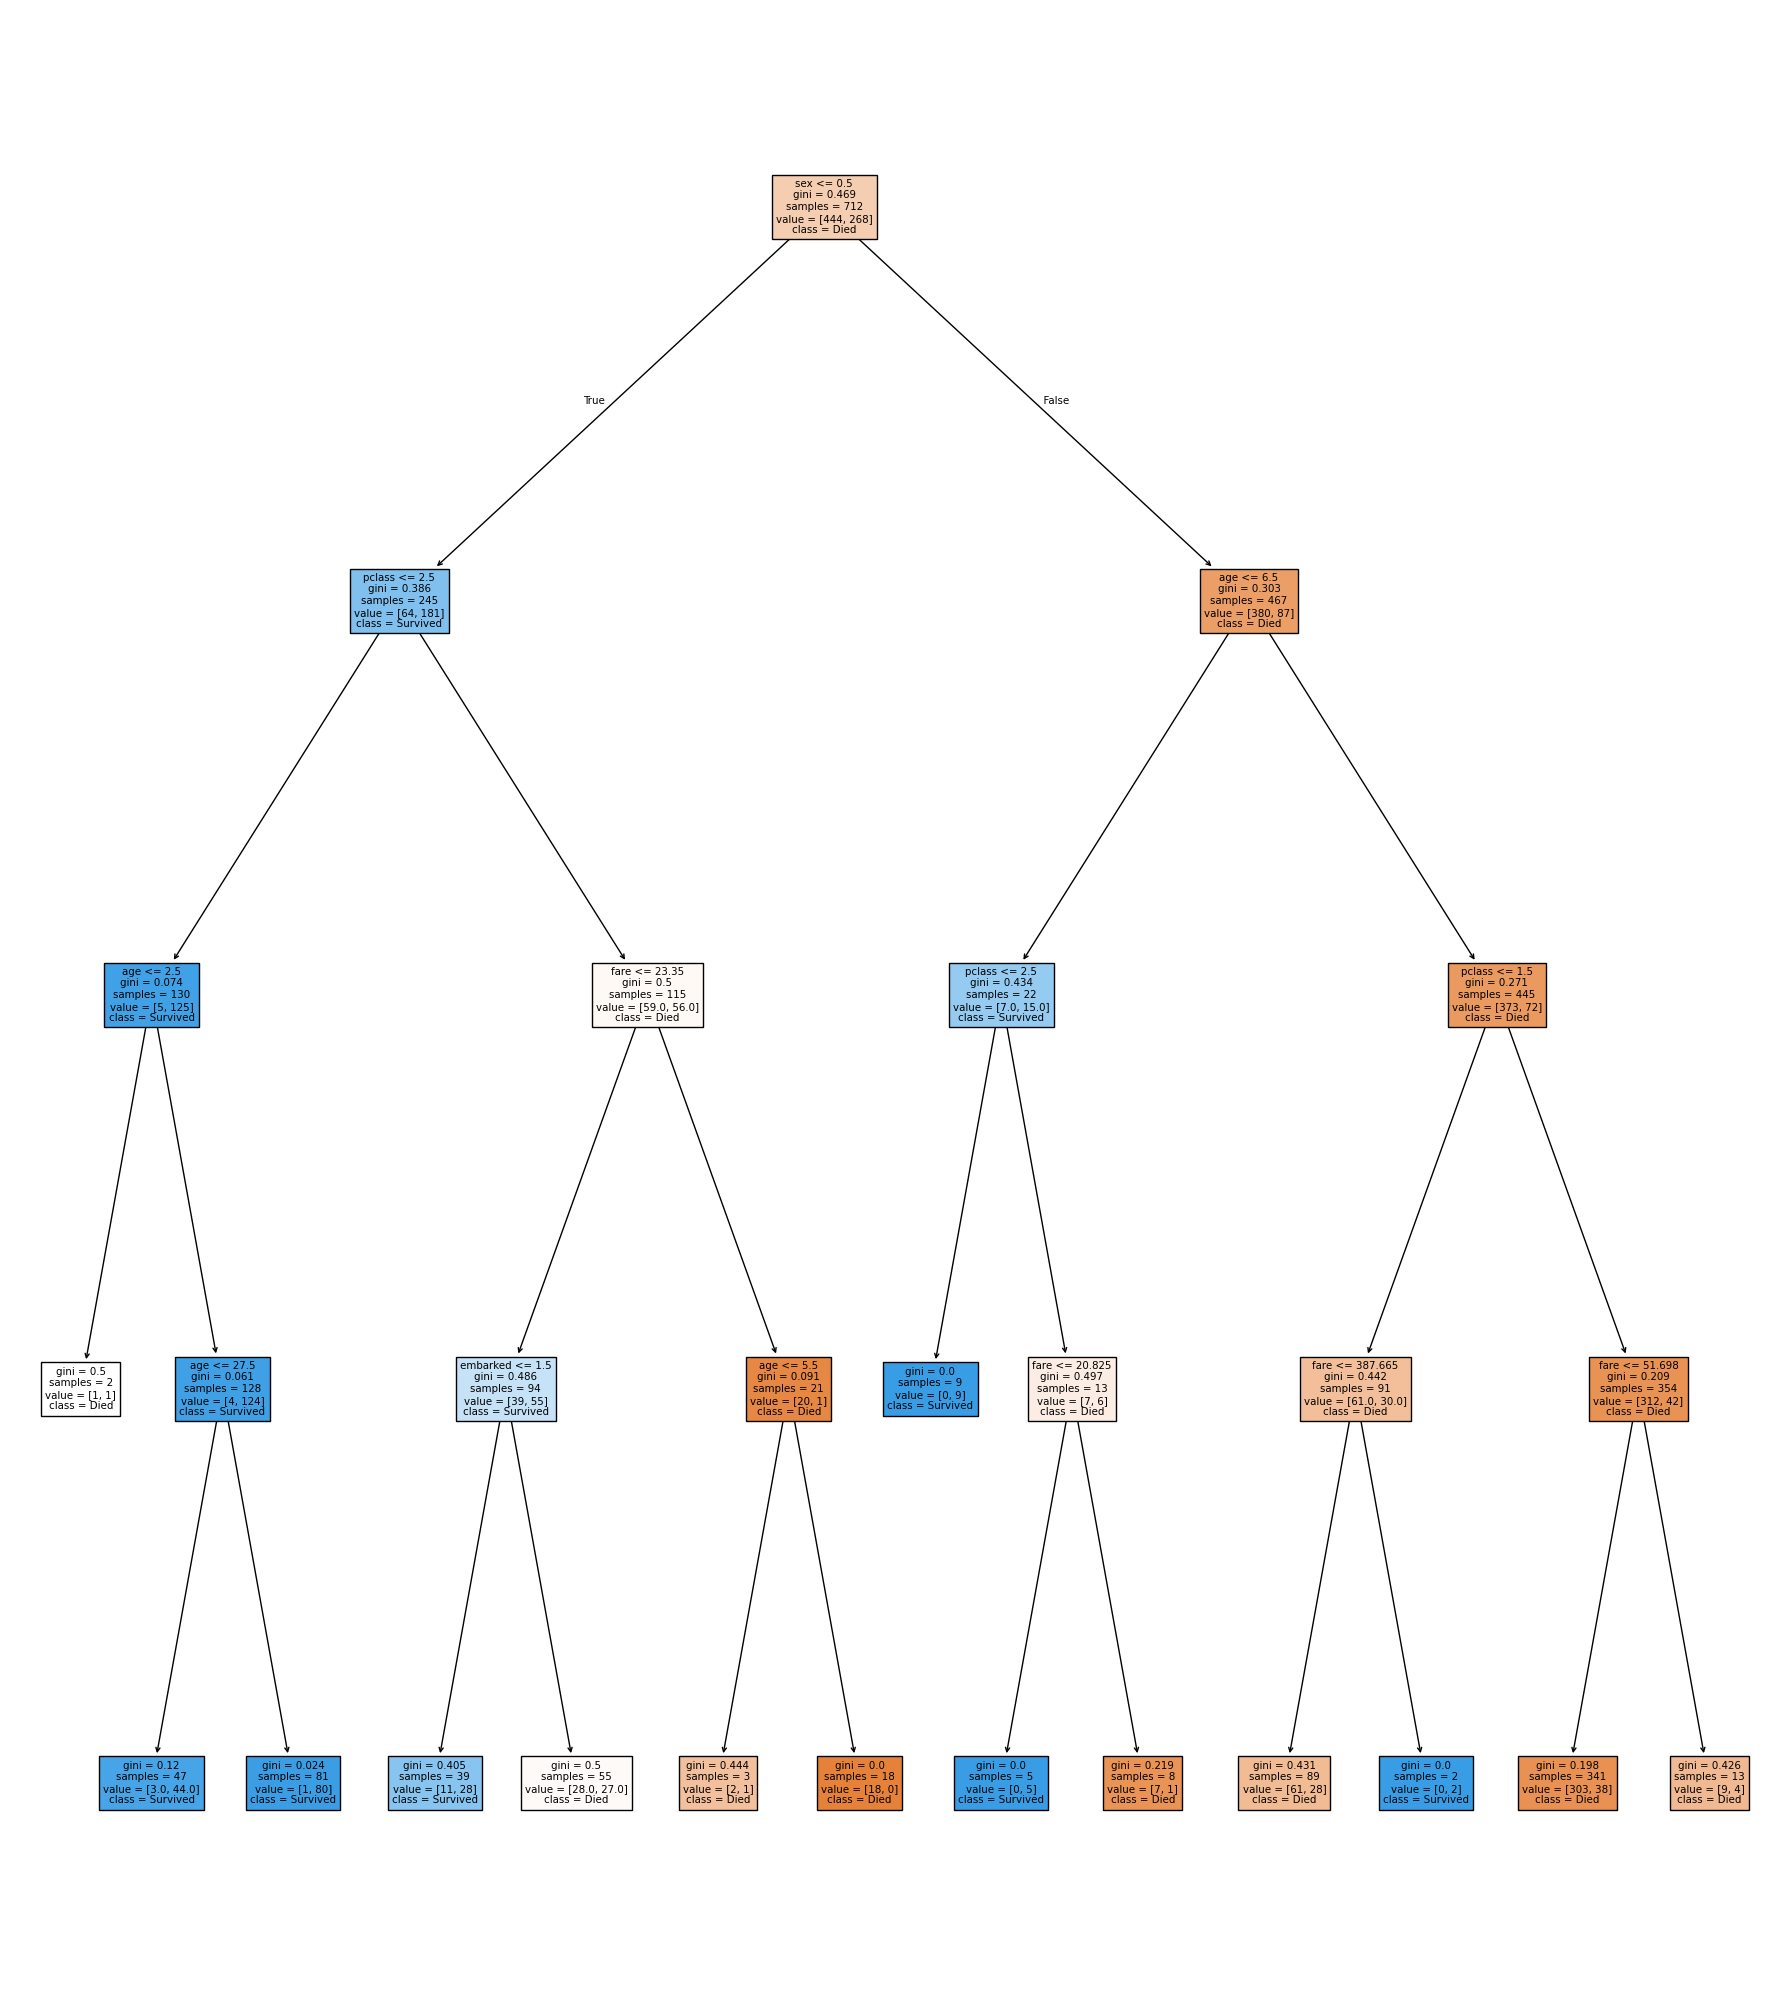

In [115]:
min_sample_splits = [5,10,15,20,25,30]

for split in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"Accuracy for split= {split} , accuracy = {acc}")

    if split==10:
        plt.figure(figsize=(18,20))
        plot_tree(
            model , 
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
         
        )

        plt.tight_layout()
    